### Load the dataset

In [1]:
import os
import numpy as np
import pandas as pd
from PIL import Image

folder_path = "UTKFace"
data = []

for filename in sorted(os.listdir(folder_path)):
    

    if not filename.endswith(".jpg"):
        continue
    try:
        # Extract age from filename
        age = int(filename.split("_")[0])
        img_path = os.path.join(folder_path, filename)
        # Append to list
        data.append([img_path, age])

    except Exception as e:
        print(f"Skipping {filename} due to error: {e}")

# Create DataFrame
df = pd.DataFrame(data, columns=["image_path", "age"])

print("Number of samples:", len(df))
df

Number of samples: 23708


,image_path,age
0,UTKFace\100_0_0_20170112213500903.jpg.chip.jpg,100
1,UTKFace\100_0_0_20170112215240346.jpg.chip.jpg,100
2,UTKFace\100_1_0_20170110183726390.jpg.chip.jpg,100
3,UTKFace\100_1_0_20170112213001988.jpg.chip.jpg,100
4,UTKFace\100_1_0_20170112213303693.jpg.chip.jpg,100
...,...,...
23703,UTKFace\9_1_3_20161220222856346.jpg.chip.jpg,9
23704,UTKFace\9_1_3_20170104222949455.jpg.chip.jpg,9
23705,UTKFace\9_1_4_20170103200637399.jpg.chip.jpg,9
23706,UTKFace\9_1_4_20170103200814791.jpg.chip.jpg,9


In [2]:
import torch
print(torch.cuda.is_available())        # Should be True
print(torch.cuda.get_device_name(0))    # Should show RTX 5060
print(torch.__version__)                # Should be 2.7+


True
NVIDIA GeForce RTX 5060 Laptop GPU
2.10.0+cu128


### Check age distribution and class imbalance

count    23708.000000
mean        33.303484
std         19.886112
min          1.000000
25%         23.000000
50%         29.000000
75%         45.000000
max        116.000000
Name: age, dtype: float64


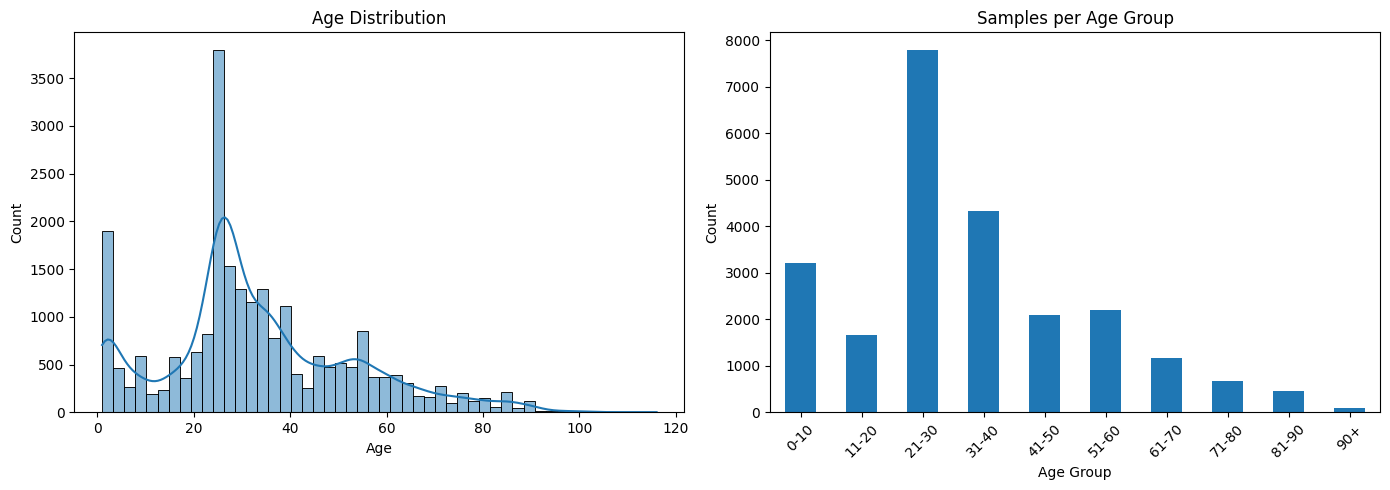

In [3]:
import matplotlib.pyplot as plt
import seaborn as sns

# Basic stats
print(df["age"].describe())

# Age distribution
plt.figure(figsize=(14, 5))

# Plot 1 - histogram
plt.subplot(1, 2, 1)
sns.histplot(df["age"], bins=50, kde=True)
plt.title("Age Distribution")
plt.xlabel("Age")
plt.ylabel("Count")

# Plot 2 - by age group (binned)
plt.subplot(1, 2, 2)
bins = [0, 10, 20, 30, 40, 50, 60, 70, 80, 90, 120]
labels = ["0-10", "11-20", "21-30", "31-40", "41-50", "51-60", "61-70", "71-80", "81-90", "90+"]
df["age_group"] = pd.cut(df["age"], bins=bins, labels=labels)
df["age_group"].value_counts().sort_index().plot(kind="bar")
plt.title("Samples per Age Group")
plt.xlabel("Age Group")
plt.ylabel("Count")
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

In [4]:
# Check exact counts for rare groups
print(df["age_group"].value_counts().sort_index())

# Check how many samples exist above 90
print(f"Samples above 90: {len(df[df['age'] > 90])}")
print(f"Max age: {df['age'].max()}")

age_group
0-10     3218
11-20    1659
21-30    7784
31-40    4339
41-50    2100
51-60    2211
61-70    1172
71-80     685
81-90     453
90+        87
Name: count, dtype: int64
Samples above 90: 87
Max age: 116


As 90+ samples are very few, we decide to clip at 90.

In [5]:
df = df[df["age"] <= 90]
print(len(df))

23621


To handle class imbalance, we will apply oversampling with data augmentation for minority classes, as well as weighted loss.
- Upsample all classes with less samples than 1,500 to this number.
- Compute sample weights
- Apply transformations to images for data augmentation

In [9]:
target_count = 1500

oversampled_groups = []
df["age_group"] = df["age_group"].cat.remove_unused_categories()

for group in df["age_group"].cat.categories:
    group_df = df[df["age_group"] == group]
    
    if len(group_df) < target_count:
        group_df = group_df.sample(target_count, replace=True, random_state=42)
    
    oversampled_groups.append(group_df)

df_balanced = pd.concat(oversampled_groups).reset_index(drop=True)

print(df_balanced["age_group"].value_counts().sort_index())
print(f"\nTotal samples: {len(df_balanced)}")

age_group
0-10     3218
11-20    1659
21-30    7784
31-40    4339
41-50    2100
51-60    2211
61-70    1500
71-80    1500
81-90    1500
Name: count, dtype: int64

Total samples: 25811


In [13]:
from sklearn.utils.class_weight import compute_sample_weight

sample_weights = compute_sample_weight(
    class_weight="balanced",
    y=df_balanced["age"]  # individual age, not group
)
df_balanced["sample_weight"] = sample_weights

# Verify - rare ages should have higher weights
print(df_balanced.groupby("age")["sample_weight"].mean().sort_index())

age
1     0.255377
2     0.594998
3     0.992349
4     1.050509
5     1.463209
        ...   
86    2.537955
87    9.559630
88    2.631091
89    2.451187
90    1.086322
Name: sample_weight, Length: 90, dtype: float64


In [14]:
from PIL import Image
import numpy as np
import os

# Compute mean and std from UTKFace images
means = []
stds = []

for path in df_balanced["image_path"]:
    img = Image.open(path).convert("RGB").resize((128, 128))
    img_array = np.array(img) / 255.0  # scale to 0-1
    means.append(img_array.mean(axis=(0, 1)))
    stds.append(img_array.std(axis=(0, 1)))

utk_mean = np.mean(means, axis=0).tolist()
utk_std = np.mean(stds, axis=0).tolist()

print(f"UTKFace mean: {utk_mean}")
print(f"UTKFace std:  {utk_std}")

UTKFace mean: [0.5974297365016903, 0.4577415686393296, 0.3923187897688508]
UTKFace std:  [0.21657992752544003, 0.19318559182849473, 0.18446899975613337]


In [16]:
import torchvision.transforms as transforms

cnn_train_transforms = transforms.Compose([
    transforms.Resize((128, 128)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2),
    transforms.RandomRotation(degrees=10),
    transforms.ToTensor(),
    transforms.Normalize(mean=utk_mean, std=utk_std)  # ← UTKFace numbers
])

cnn_val_transforms = transforms.Compose([
    transforms.Resize((128, 128)),
    transforms.ToTensor(),
    transforms.Normalize(mean=utk_mean, std=utk_std)  # ← UTKFace numbers
])

pretrained_train_transforms = transforms.Compose([
    transforms.Resize((128, 128)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2),
    transforms.RandomRotation(degrees=10),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],  # ← ImageNet numbers
                         std=[0.229, 0.224, 0.225])
])

pretrained_val_transforms = transforms.Compose([
    transforms.Resize((128, 128)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],  # ← ImageNet numbers
                         std=[0.229, 0.224, 0.225])
])

In [17]:
df_balanced

,image_path,age,age_group,sample_weight
0,UTKFace\10_0_0_20161220222308131.jpg.chip.jpg,10,0-10,1.838390
1,UTKFace\10_0_0_20170103200329407.jpg.chip.jpg,10,0-10,1.838390
2,UTKFace\10_0_0_20170103200522151.jpg.chip.jpg,10,0-10,1.838390
3,UTKFace\10_0_0_20170103233459275.jpg.chip.jpg,10,0-10,1.838390
4,UTKFace\10_0_0_20170104013211746.jpg.chip.jpg,10,0-10,1.838390
...,...,...,...,...
25806,UTKFace\89_0_1_20170117182437361.jpg.chip.jpg,89,81-90,2.451187
25807,UTKFace\83_0_0_20170111211106903.jpg.chip.jpg,83,81-90,6.669509
25808,UTKFace\85_1_0_20170110183131183.jpg.chip.jpg,85,81-90,0.539077
25809,UTKFace\89_1_0_20170120225533673.jpg.chip.jpg,89,81-90,2.451187


### Train, val, test splitting

In [18]:
from sklearn.model_selection import train_test_split

X = df_balanced['image_path']
y = df_balanced['age']
groups = df_balanced['age_group']
weights = df_balanced['sample_weight']

# First split - 80% train, 20% temp
X_train, X_temp, y_train, y_temp, w_train, w_temp, g_train, g_temp = train_test_split(
    X, y, weights, groups,
    test_size=0.2, random_state=42, shuffle=True, stratify=groups
)

# Second split - 50/50 val and test from temp
X_val, X_test, y_val, y_test, w_val, w_test = train_test_split(
    X_temp, y_temp, w_temp,
    test_size=0.5, random_state=42, shuffle=True, stratify=g_temp
)

print(f"Train: {len(X_train)} | Val: {len(X_val)} | Test: {len(X_test)}")

Train: 20648 | Val: 2581 | Test: 2582
